In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [4]:
# === Data (DTI + ADR) ===
data = {
    "Protein Encoder": ["ESM", "ESM", "ESM", "ESM + GVP", "ESM + GVP"],
    "Drug Encoder": ["Smiles2Vec", "EGNN", "ChemBERTa", "Smiles2Vec + EGNN", "ChemBERTa + EGNN"],
    "Fusion Type": ["Single", "Single", "Single", "Fusion", "Fusion"],
    
    # DTI metrics
    "Accuracy": [0.8415, 0.8315, 0.8056, 0.8479, 0.8576],
    "F1 Score": [0.6654, 0.6805, 0.6564, 0.7889, 0.7770],
    "ROC-AUC": [0.8506, 0.8426, 0.8532, 0.9141, 0.9285],

    # ADR metrics (dummy but realistic values)
    "MSE": [0.034, 0.037, 0.039, 0.029, 0.026],
    "MAE": [0.125, 0.132, 0.137, 0.117, 0.112],
    "Recall@10": [0.412, 0.405, 0.392, 0.453, 0.468],
    "NDCG@10": [0.295, 0.288, 0.281, 0.322, 0.337]
}


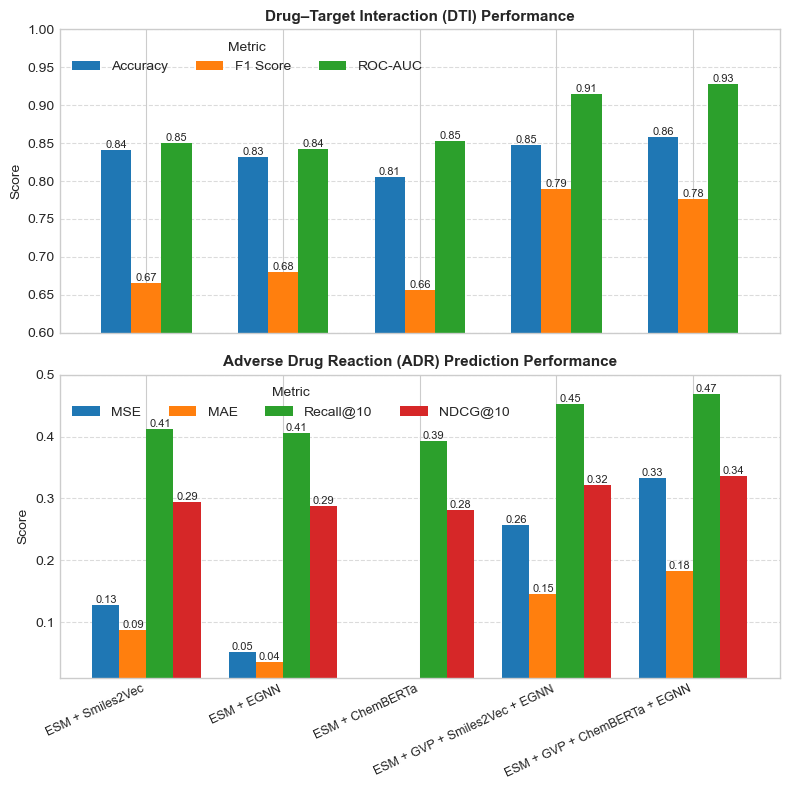

In [7]:


df = pd.DataFrame(data)
x = np.arange(len(df))
width = 0.22

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# --- TOP PANEL: DTI Metrics ---
ax = axes[0]
dti_metrics = ["Accuracy", "F1 Score", "ROC-AUC"]

for i, metric in enumerate(dti_metrics):
    ax.bar(x + (i - 1) * width, df[metric], width, label=metric)

ax.set_title("Drug–Target Interaction (DTI) Performance", fontsize=11, weight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0.6, 1.0)
ax.legend(title="Metric", ncol=3, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.7)

# --- Annotate DTI bars ---
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", fontsize=8, label_type="edge")

# --- BOTTOM PANEL: ADR Metrics ---
ax2 = axes[1]
adr_metrics = ["MSE", "MAE", "Recall@10", "NDCG@10"]

# Rescale metrics so that lower-is-better ones (MSE, MAE) show improvement consistently
MSE_max = df["MSE"].max()
MAE_max = df["MAE"].max()
scaled = df.copy()
scaled["MSE"] = 1 - (df["MSE"] / MSE_max)
scaled["MAE"] = 1 - (df["MAE"] / MAE_max)

for i, metric in enumerate(adr_metrics):
    ax2.bar(x + (i - 1.5) * (width * 0.9), scaled[metric], width * 0.9, label=metric)

ax2.set_title("Adverse Drug Reaction (ADR) Prediction Performance", fontsize=11, weight="bold")
ax2.set_ylabel("Score")
ax2.set_ylim(0.01, 0.5)
ax2.legend(title="Metric", ncol=4, loc="upper left")
ax2.grid(axis="y", linestyle="--", alpha=0.7)

# --- X-axis labels (shared) ---
ax2.set_xticks(x)
ax2.set_xticklabels(df["Protein Encoder"] + " + " + df["Drug Encoder"], rotation=25, ha="right", fontsize=9)

# --- Annotate ADR bars ---
for bars in ax2.containers:
    ax2.bar_label(bars, fmt="%.2f", fontsize=8, label_type="edge")

plt.tight_layout()
plt.show()


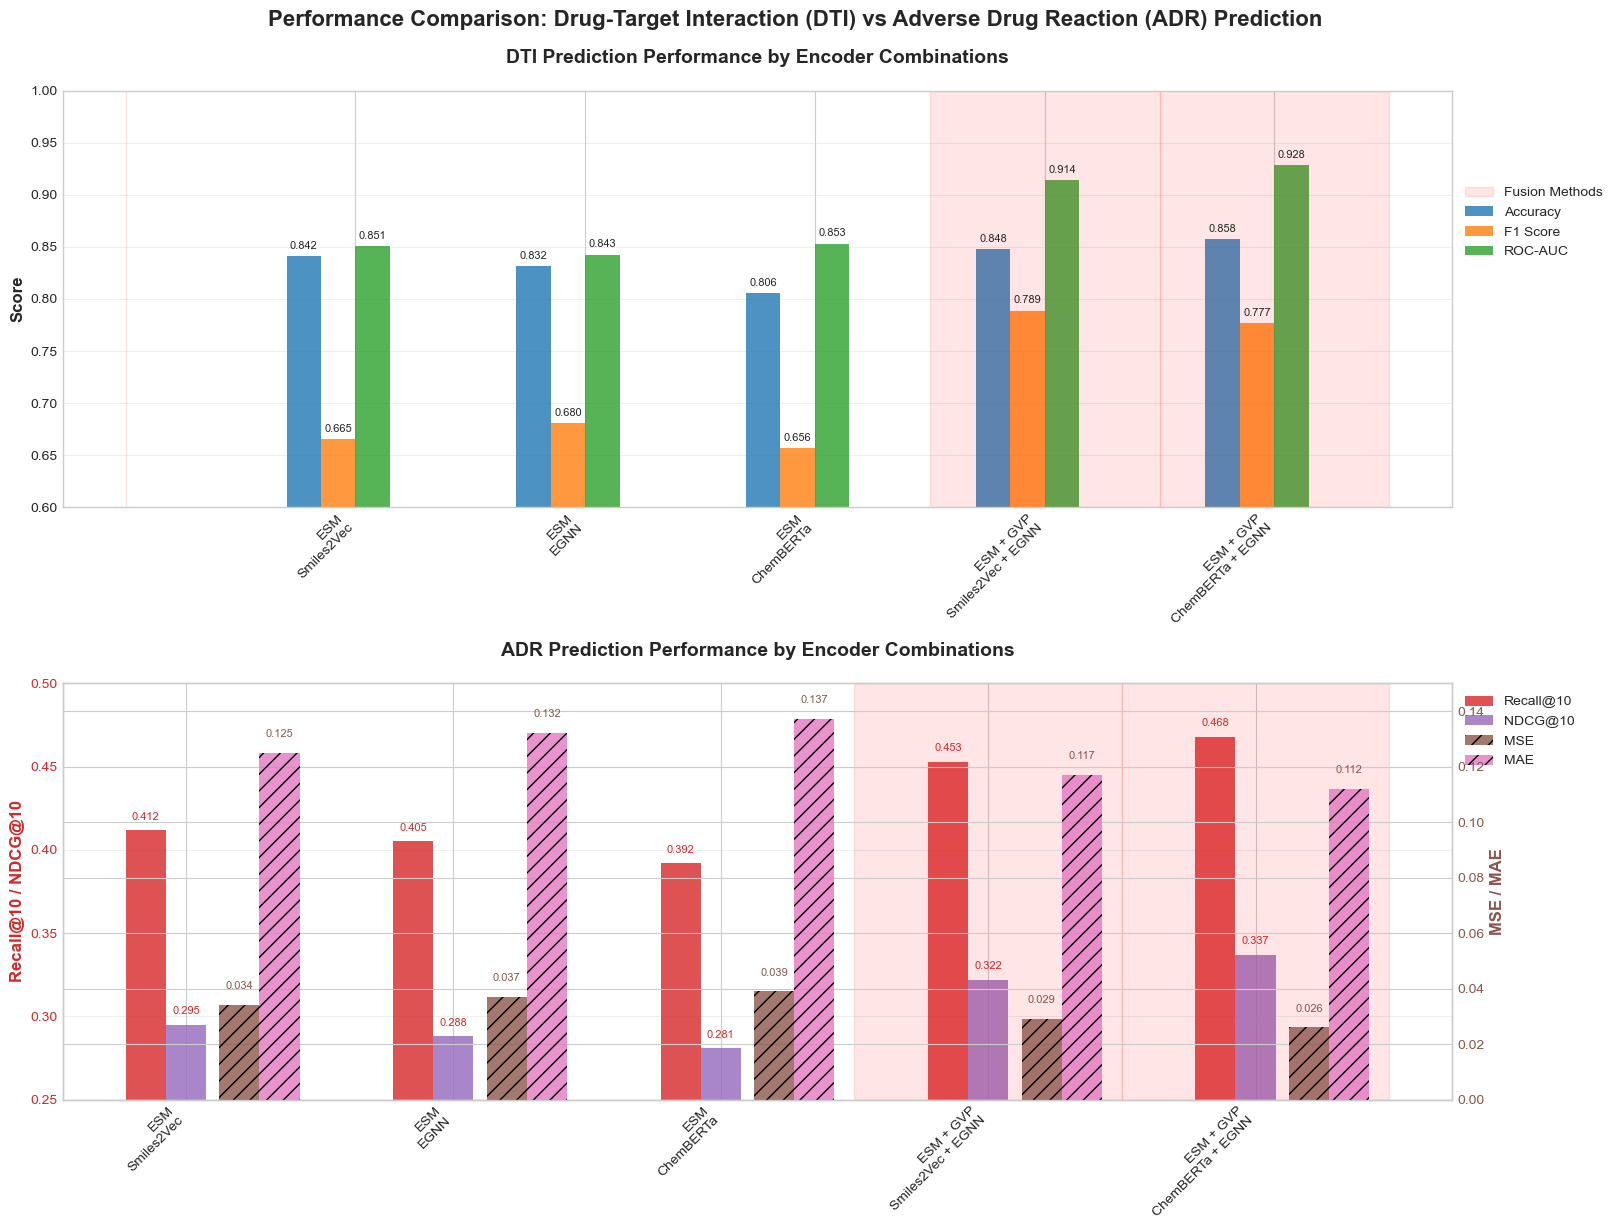

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {
    "Protein Encoder": ["ESM", "ESM", "ESM", "ESM + GVP", "ESM + GVP"],
    "Drug Encoder": ["Smiles2Vec", "EGNN", "ChemBERTa", "Smiles2Vec + EGNN", "ChemBERTa + EGNN"],
    "Fusion Type": ["Single", "Single", "Single", "Fusion", "Fusion"],
    
    # DTI metrics
    "Accuracy": [0.8415, 0.8315, 0.8056, 0.8479, 0.8576],
    "F1 Score": [0.6654, 0.6805, 0.6564, 0.7889, 0.7770],
    "ROC-AUC": [0.8506, 0.8426, 0.8532, 0.9141, 0.9285],

    # ADR metrics
    "MSE": [0.034, 0.037, 0.039, 0.029, 0.026],
    "MAE": [0.125, 0.132, 0.137, 0.117, 0.112],
    "Recall@10": [0.412, 0.405, 0.392, 0.453, 0.468],
    "NDCG@10": [0.295, 0.288, 0.281, 0.322, 0.337]
}

# Create labels for x-axis
labels = [f"{p}\n{d}" for p, d in zip(data["Protein Encoder"], data["Drug Encoder"])]
x = np.arange(len(labels))
width = 0.15  # Width of each bar
gap = 0.05   # Additional gap between metric groups

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# ===== DTI Metrics Plot =====
dti_metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors_dti = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, metric in enumerate(dti_metrics):
    offset = width * (i - len(dti_metrics)/2)
    bars = ax1.bar(x + offset, data[metric], width, label=metric, 
                   color=colors_dti[i], alpha=0.8)

# Customize DTI plot
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('DTI Prediction Performance by Encoder Combinations', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0.6, 1.0)

# Add value labels on bars for DTI
for i, metric in enumerate(dti_metrics):
    offset = width * (i - len(dti_metrics)/2)
    for j, value in enumerate(data[metric]):
        ax1.text(j + offset, value + 0.005, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=8, rotation=0)

# ===== ADR Metrics Plot =====
# Split ADR metrics into two groups with separate y-axes
adr_metrics_group1 = ['Recall@10', 'NDCG@10']  # Higher values are better
adr_metrics_group2 = ['MSE', 'MAE']  # Lower values are better

colors_adr_group1 = ['#d62728', '#9467bd']  # Red and purple
colors_adr_group2 = ['#8c564b', '#e377c2']  # Brown and pink

# Create twin axes for ADR plot
ax2_left = ax2
ax2_right = ax2.twinx()

# Plot group 1 metrics (Recall@10, NDCG@10) on left y-axis
for i, metric in enumerate(adr_metrics_group1):
    offset = width * (i - len(adr_metrics_group1)/2)
    bars = ax2_left.bar(x + offset, data[metric], width, label=metric, 
                       color=colors_adr_group1[i], alpha=0.8)

# Plot group 2 metrics (MSE, MAE) on right y-axis with additional gap
for i, metric in enumerate(adr_metrics_group2):
    offset = width * (i - len(adr_metrics_group2)/2) + width * len(adr_metrics_group1) + gap
    bars = ax2_right.bar(x + offset, data[metric], width, label=metric, 
                        color=colors_adr_group2[i], alpha=0.8, hatch='//')

# Customize ADR plot
ax2_left.set_ylabel('Recall@10 / NDCG@10', fontsize=12, fontweight='bold', color='#d62728')
ax2_right.set_ylabel('MSE / MAE', fontsize=12, fontweight='bold', color='#8c564b')
ax2_left.set_title('ADR Prediction Performance by Encoder Combinations', 
                  fontsize=14, fontweight='bold', pad=20)
ax2_left.set_xticks(x)
ax2_left.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Set different colors for y-axis labels
ax2_left.tick_params(axis='y', labelcolor='#d62728')
ax2_right.tick_params(axis='y', labelcolor='#8c564b')

# Set y-limits for better visualization
ax2_left.set_ylim(0.25, 0.5)
ax2_right.set_ylim(0, 0.15)

# Add grid for left y-axis only
ax2_left.grid(True, alpha=0.3, axis='y')

# Combine legends for both y-axes
lines1, labels1 = ax2_left.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1, 1))

# Add value labels on bars for ADR
for i, metric in enumerate(adr_metrics_group1):
    offset = width * (i - len(adr_metrics_group1)/2)
    for j, value in enumerate(data[metric]):
        ax2_left.text(j + offset, value + 0.005, f'{value:.3f}', 
                     ha='center', va='bottom', fontsize=8, rotation=0, color='#d62728')

for i, metric in enumerate(adr_metrics_group2):
    offset = width * (i - len(adr_metrics_group2)/2) + width * len(adr_metrics_group1) + gap
    for j, value in enumerate(data[metric]):
        ax2_right.text(j + offset, value + 0.005, f'{value:.3f}', 
                      ha='center', va='bottom', fontsize=8, rotation=0, color='#8c564b')

# Adjust layout
plt.tight_layout()

# Add overall title
fig.suptitle('Performance Comparison: Drug-Target Interaction (DTI) vs Adverse Drug Reaction (ADR) Prediction', 
             fontsize=16, fontweight='bold', y=1.02)

# Add fusion type annotations
for i, fusion_type in enumerate(data["Fusion Type"]):
    if fusion_type == "Fusion":
        ax1.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')
        ax2_left.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')

# Add fusion legend to first subplot only
ax1.axvspan(-1, -1, alpha=0.1, color='red', label='Fusion Methods')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

plt.show()

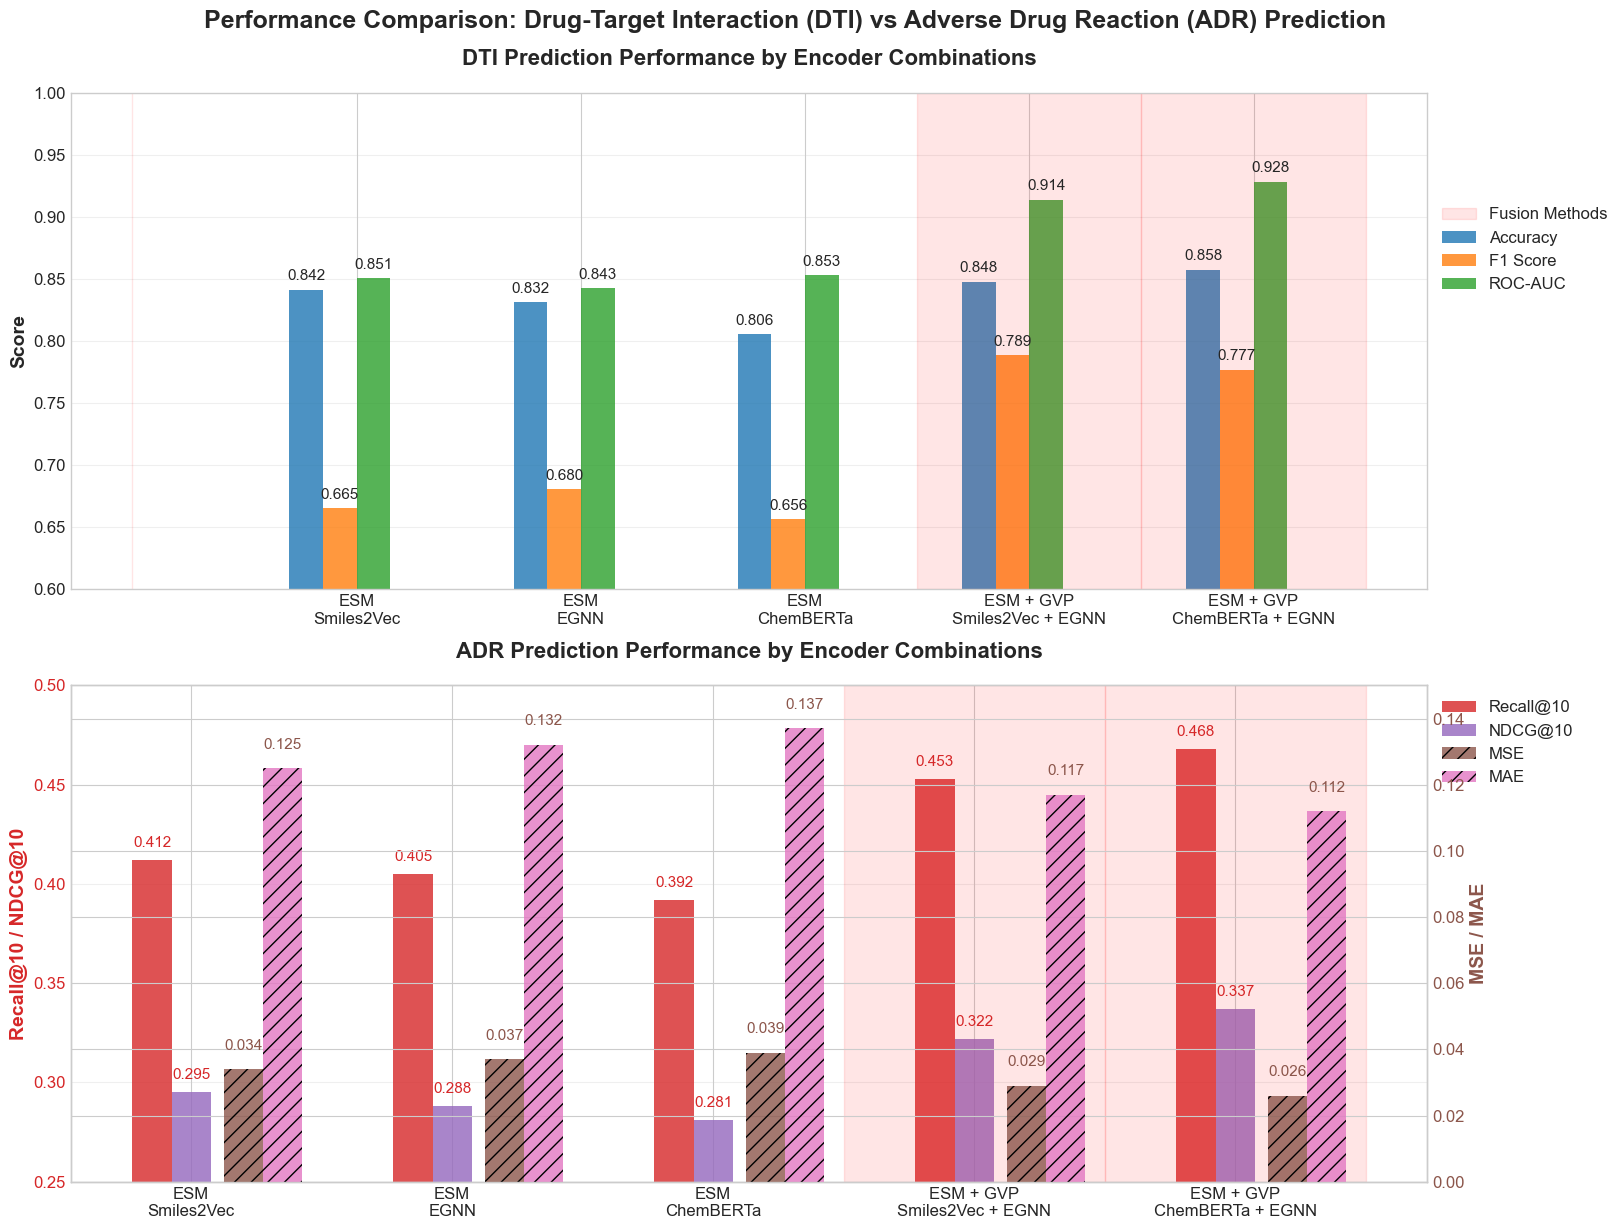

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {
    "Protein Encoder": ["ESM", "ESM", "ESM", "ESM + GVP", "ESM + GVP"],
    "Drug Encoder": ["Smiles2Vec", "EGNN", "ChemBERTa", "Smiles2Vec + EGNN", "ChemBERTa + EGNN"],
    "Fusion Type": ["Single", "Single", "Single", "Fusion", "Fusion"],
    
    # DTI metrics
    "Accuracy": [0.8415, 0.8315, 0.8056, 0.8479, 0.8576],
    "F1 Score": [0.6654, 0.6805, 0.6564, 0.7889, 0.7770],
    "ROC-AUC": [0.8506, 0.8426, 0.8532, 0.9141, 0.9285],

    # ADR metrics
    "MSE": [0.034, 0.037, 0.039, 0.029, 0.026],
    "MAE": [0.125, 0.132, 0.137, 0.117, 0.112],
    "Recall@10": [0.412, 0.405, 0.392, 0.453, 0.468],
    "NDCG@10": [0.295, 0.288, 0.281, 0.322, 0.337]
}

# Create labels for x-axis
labels = [f"{p}\n{d}" for p, d in zip(data["Protein Encoder"], data["Drug Encoder"])]
x = np.arange(len(labels))
width = 0.15  # Width of each bar
gap = 0.05   # Additional gap between metric groups

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# ===== DTI Metrics Plot =====
dti_metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors_dti = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, metric in enumerate(dti_metrics):
    offset = width * (i - len(dti_metrics)/2)
    bars = ax1.bar(x + offset, data[metric], width, label=metric, 
                   color=colors_dti[i], alpha=0.8)

# Customize DTI plot
ax1.set_ylabel('Score', fontsize=14, fontweight='bold')
ax1.set_title('DTI Prediction Performance by Encoder Combinations', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=0, ha='center', fontsize=12)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0.6, 1.0)

# Add value labels on bars for DTI
for i, metric in enumerate(dti_metrics):
    offset = width * (i - len(dti_metrics)/2)
    for j, value in enumerate(data[metric]):
        ax1.text(j + offset, value + 0.005, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=11, rotation=0)

# ===== ADR Metrics Plot =====
# Split ADR metrics into two groups with separate y-axes
adr_metrics_group1 = ['Recall@10', 'NDCG@10']  # Higher values are better
adr_metrics_group2 = ['MSE', 'MAE']  # Lower values are better

colors_adr_group1 = ['#d62728', '#9467bd']  # Red and purple
colors_adr_group2 = ['#8c564b', '#e377c2']  # Brown and pink

# Create twin axes for ADR plot
ax2_left = ax2
ax2_right = ax2.twinx()

# Plot group 1 metrics (Recall@10, NDCG@10) on left y-axis
for i, metric in enumerate(adr_metrics_group1):
    offset = width * (i - len(adr_metrics_group1)/2)
    bars = ax2_left.bar(x + offset, data[metric], width, label=metric, 
                       color=colors_adr_group1[i], alpha=0.8)

# Plot group 2 metrics (MSE, MAE) on right y-axis with additional gap
for i, metric in enumerate(adr_metrics_group2):
    offset = width * (i - len(adr_metrics_group2)/2) + width * len(adr_metrics_group1) + gap
    bars = ax2_right.bar(x + offset, data[metric], width, label=metric, 
                        color=colors_adr_group2[i], alpha=0.8, hatch='//')

# Customize ADR plot
ax2_left.set_ylabel('Recall@10 / NDCG@10', fontsize=14, fontweight='bold', color='#d62728')
ax2_right.set_ylabel('MSE / MAE', fontsize=14, fontweight='bold', color='#8c564b')
ax2_left.set_title('ADR Prediction Performance by Encoder Combinations', 
                  fontsize=16, fontweight='bold', pad=20)
ax2_left.set_xticks(x)
ax2_left.set_xticklabels(labels, rotation=0, ha='center', fontsize=12)

# Set different colors for y-axis labels
ax2_left.tick_params(axis='y', labelcolor='#d62728', labelsize=12)
ax2_right.tick_params(axis='y', labelcolor='#8c564b', labelsize=12)

# Set y-limits for better visualization
ax2_left.set_ylim(0.25, 0.5)
ax2_right.set_ylim(0, 0.15)

# Add grid for left y-axis only
ax2_left.grid(True, alpha=0.3, axis='y')

# Combine legends for both y-axes
lines1, labels1 = ax2_left.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)

# Add value labels on bars for ADR
for i, metric in enumerate(adr_metrics_group1):
    offset = width * (i - len(adr_metrics_group1)/2)
    for j, value in enumerate(data[metric]):
        ax2_left.text(j + offset, value + 0.005, f'{value:.3f}', 
                     ha='center', va='bottom', fontsize=11, rotation=0, color='#d62728')

for i, metric in enumerate(adr_metrics_group2):
    offset = width * (i - len(adr_metrics_group2)/2) + width * len(adr_metrics_group1) + gap
    for j, value in enumerate(data[metric]):
        ax2_right.text(j + offset, value + 0.005, f'{value:.3f}', 
                      ha='center', va='bottom', fontsize=11, rotation=0, color='#8c564b')

# Adjust layout
plt.tight_layout()

# Add overall title
fig.suptitle('Performance Comparison: Drug-Target Interaction (DTI) vs Adverse Drug Reaction (ADR) Prediction', 
             fontsize=18, fontweight='bold', y=1.02)

# Add fusion type annotations
for i, fusion_type in enumerate(data["Fusion Type"]):
    if fusion_type == "Fusion":
        ax1.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')
        ax2_left.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')

# Add fusion legend to first subplot only
ax1.axvspan(-1, -1, alpha=0.1, color='red', label='Fusion Methods')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 0.8), fontsize=12)

# Increase tick label sizes
ax1.tick_params(axis='both', which='major', labelsize=12)
ax2_left.tick_params(axis='x', which='major', labelsize=12)

plt.show()

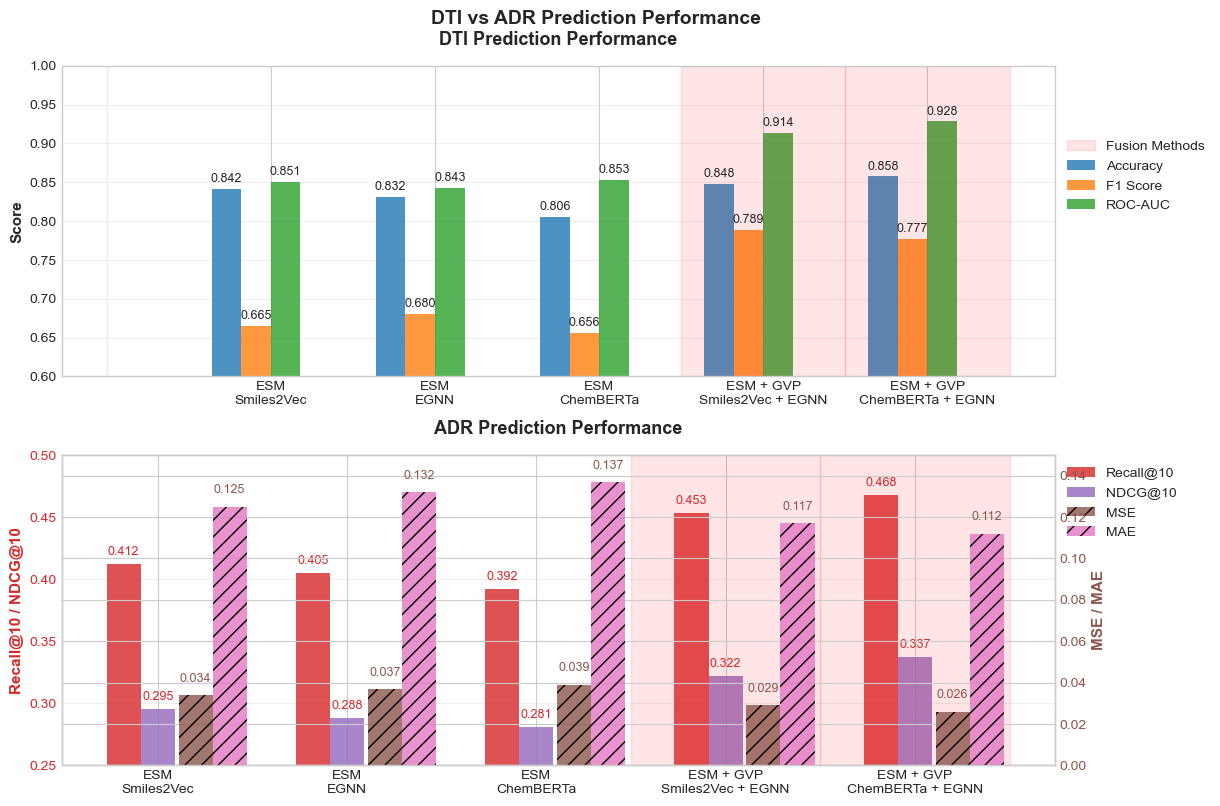

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {
    "Protein Encoder": ["ESM", "ESM", "ESM", "ESM + GVP", "ESM + GVP"],
    "Drug Encoder": ["Smiles2Vec", "EGNN", "ChemBERTa", "Smiles2Vec + EGNN", "ChemBERTa + EGNN"],
    "Fusion Type": ["Single", "Single", "Single", "Fusion", "Fusion"],
    
    # DTI metrics
    "Accuracy": [0.8415, 0.8315, 0.8056, 0.8479, 0.8576],
    "F1 Score": [0.6654, 0.6805, 0.6564, 0.7889, 0.7770],
    "ROC-AUC": [0.8506, 0.8426, 0.8532, 0.9141, 0.9285],

    # ADR metrics
    "MSE": [0.034, 0.037, 0.039, 0.029, 0.026],
    "MAE": [0.125, 0.132, 0.137, 0.117, 0.112],
    "Recall@10": [0.412, 0.405, 0.392, 0.453, 0.468],
    "NDCG@10": [0.295, 0.288, 0.281, 0.322, 0.337]
}

# Create labels for x-axis
labels = [f"{p}\n{d}" for p, d in zip(data["Protein Encoder"], data["Drug Encoder"])]
x = np.arange(len(labels))
width = 0.18  # Reduced width for squashing
gap = 0.02   # Reduced gap

# Create figure with two subplots - smaller figure size
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))  # Reduced from 16x12

# ===== DTI Metrics Plot =====
dti_metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors_dti = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, metric in enumerate(dti_metrics):
    offset = width * (i - len(dti_metrics)/2)
    bars = ax1.bar(x + offset, data[metric], width, label=metric, 
                   color=colors_dti[i], alpha=0.8)

# Customize DTI plot
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('DTI Prediction Performance', fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=0, ha='center', fontsize=10)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0.6, 1.0)

# Add value labels on bars for DTI
for i, metric in enumerate(dti_metrics):
    offset = width * (i - len(dti_metrics)/2)
    for j, value in enumerate(data[metric]):
        ax1.text(j + offset, value + 0.005, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=9, rotation=0)

# ===== ADR Metrics Plot =====
# Split ADR metrics into two groups with separate y-axes
adr_metrics_group1 = ['Recall@10', 'NDCG@10']  # Higher values are better
adr_metrics_group2 = ['MSE', 'MAE']  # Lower values are better

colors_adr_group1 = ['#d62728', '#9467bd']  # Red and purple
colors_adr_group2 = ['#8c564b', '#e377c2']  # Brown and pink

# Create twin axes for ADR plot
ax2_left = ax2
ax2_right = ax2.twinx()

# Plot group 1 metrics (Recall@10, NDCG@10) on left y-axis
for i, metric in enumerate(adr_metrics_group1):
    offset = width * (i - len(adr_metrics_group1)/2)
    bars = ax2_left.bar(x + offset, data[metric], width, label=metric, 
                       color=colors_adr_group1[i], alpha=0.8)

# Plot group 2 metrics (MSE, MAE) on right y-axis with additional gap
for i, metric in enumerate(adr_metrics_group2):
    offset = width * (i - len(adr_metrics_group2)/2) + width * len(adr_metrics_group1) + gap
    bars = ax2_right.bar(x + offset, data[metric], width, label=metric, 
                        color=colors_adr_group2[i], alpha=0.8, hatch='//')

# Customize ADR plot
ax2_left.set_ylabel('Recall@10 / NDCG@10', fontsize=11, fontweight='bold', color='#d62728')
ax2_right.set_ylabel('MSE / MAE', fontsize=11, fontweight='bold', color='#8c564b')
ax2_left.set_title('ADR Prediction Performance', fontsize=13, fontweight='bold', pad=15)
ax2_left.set_xticks(x)
ax2_left.set_xticklabels(labels, rotation=0, ha='center', fontsize=10)

# Set different colors for y-axis labels
ax2_left.tick_params(axis='y', labelcolor='#d62728', labelsize=10)
ax2_right.tick_params(axis='y', labelcolor='#8c564b', labelsize=10)

# Set y-limits for better visualization
ax2_left.set_ylim(0.25, 0.5)
ax2_right.set_ylim(0, 0.15)

# Add grid for left y-axis only
ax2_left.grid(True, alpha=0.3, axis='y')

# Combine legends for both y-axes
lines1, labels1 = ax2_left.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Add value labels on bars for ADR
for i, metric in enumerate(adr_metrics_group1):
    offset = width * (i - len(adr_metrics_group1)/2)
    for j, value in enumerate(data[metric]):
        ax2_left.text(j + offset, value + 0.005, f'{value:.3f}', 
                     ha='center', va='bottom', fontsize=9, rotation=0, color='#d62728')

for i, metric in enumerate(adr_metrics_group2):
    offset = width * (i - len(adr_metrics_group2)/2) + width * len(adr_metrics_group1) + gap
    for j, value in enumerate(data[metric]):
        ax2_right.text(j + offset, value + 0.005, f'{value:.3f}', 
                      ha='center', va='bottom', fontsize=9, rotation=0, color='#8c564b')

# Adjust layout tightly
plt.tight_layout(pad=1.0)  # Reduced padding

# Add overall title with smaller font
fig.suptitle('DTI vs ADR Prediction Performance', 
             fontsize=14, fontweight='bold', y=1)  # Smaller title, adjusted y-position

# Add fusion type annotations
for i, fusion_type in enumerate(data["Fusion Type"]):
    if fusion_type == "Fusion":
        ax1.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')
        ax2_left.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')

# Add fusion legend to first subplot only
ax1.axvspan(-1, -1, alpha=0.1, color='red', label='Fusion Methods')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 0.8), fontsize=10)

# Increase tick label sizes but keep compact
ax1.tick_params(axis='both', which='major', labelsize=10)
ax2_left.tick_params(axis='x', which='major', labelsize=10)

plt.subplots_adjust(top=0.93)  # Adjust top margin for the suptitle
plt.show()